In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
import numpy as np
import pandas
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from scipy import optimize
from scipy.io import loadmat
%matplotlib inline

In [40]:
def normalizar(_x):
    _sigma = np.std(_x, axis=0)
    _mu = np.mean(_x, axis=0)
    _sigma[_sigma == 0] = 1
    
    X_norm = (_x - _mu) / _sigma
    
    return X_norm, _mu, _sigma


In [37]:
input_layer_size  = 784
num_labels = 10

data = loadmat('drive/MyDrive/datasets/emnist-digits.mat')
x = data['dataset'][0][0][0][0][0]['images']
y = data['dataset'][0][0][0][0][0]['labels'].ravel()


In [41]:
x_norm, mu, sigma = normalizar(x)

In [43]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

In [44]:
y

array([8, 9, 6, ..., 1, 1, 0], dtype=uint8)

In [45]:
y[y == 10] = 0

m = y.size

In [46]:
def displayData(X, example_width=None, figsize=(10, 10)):
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensinal.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n / example_width

    # Calcula el numero de elementos a mostrar
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(example_width, example_width, order='F'),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')

In [47]:
pandas.DataFrame(y).value_counts().sort_index()

,count
0,
0,24000
1,24000
2,24000
3,24000
4,24000
5,24000
6,24000
7,24000
8,24000


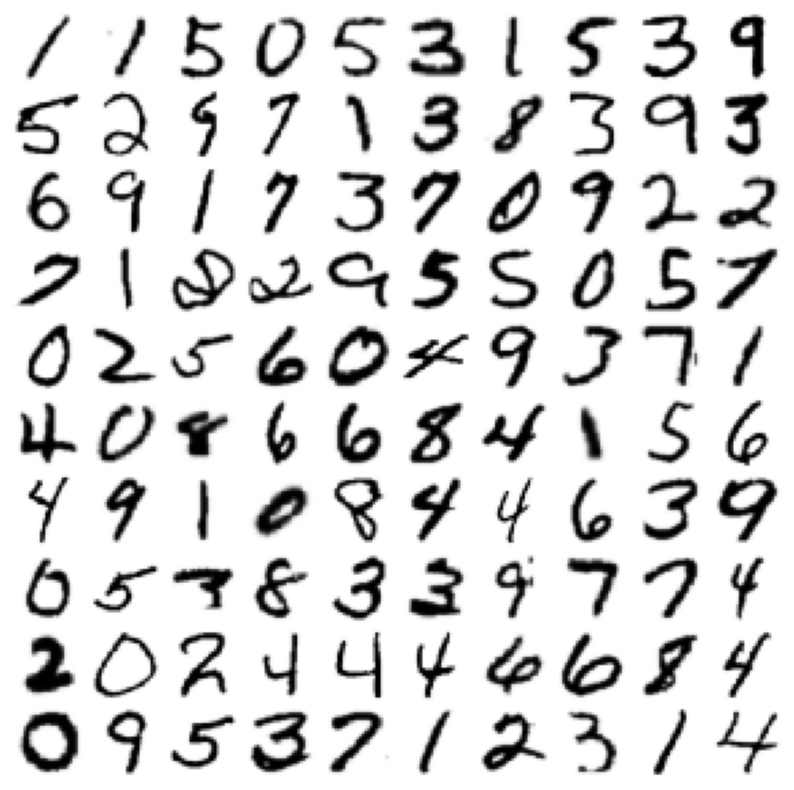

In [48]:
# Selecciona aleatoriamente 100 puntos de datos para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
sel = x[rand_indices, :]

displayData(sel)

In [49]:
'''
# valores de prueba para los parámetros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)
print(X_t)
# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

'''
# valores de testeo para el parametro de regularizacion
lambda_t = 3

In [50]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [51]:
def lrCostFunction(_theta, _x, _y, _lambda):
    # Inicializa algunos valores utiles
    m = _y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if _y.dtype == bool:
        _y = _y.astype(int)


    J = 0
    grad = np.zeros(_theta.shape)

    h = sigmoid(_x.dot(_theta.T))
    
    temp = _theta
    temp[0] = 0

    J = (1 / m) * np.sum(-_y.dot(np.log(h)) - (1 - _y).dot(np.log(1 - h))) + (_lambda / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - _y).dot(_x)
    grad = grad + (_lambda / m) * temp

    return J, grad

In [52]:
J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)

print('Costo         : {:.6f}'.format(J))
print('Costo esperadot: 2.534819')
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))
print('Gradientes esperados:')
print(' [0.146561, -0.548558, 0.724722, 1.398003]');

Costo         : 2.534819
Costo esperadot: 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]
Gradientes esperados:
 [0.146561, -0.548558, 0.724722, 1.398003]


<a id="section2"></a>
### 1.4 Clasificacion One-vs-all
En esta parte del ejercicio, se implementará la clasificación de uno contra todos mediante el entrenamiento de múltiples clasificadores de regresión logística regularizados, uno para cada una de las clases $K$ en nuestro conjunto de datos. En el conjunto de datos de dígitos escritos a mano, $K = 10$, pero su código debería funcionar para cualquier valor de $K$.

El argumento `y` de esta función es un vector de etiquetas de 0 a 9. Al entrenar el clasificador para la clase $k \in \{0, ..., K-1 \} $, querrá un vector K-dimensional de etiquetas $y$, donde $y_j \ in 0, 1$ indica si la instancia de entrenamiento $j ^ {th}$ pertenece a la clase $k$ $(y_j = 1)$, o si pertenece a una clase diferente $(y_j = 0)$.

Además, se utiliza `optimize.minimize` de scipy para este ejercicio.
<a id="oneVsAll"></a>

In [53]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))

    # Agrega unos a la matriz X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 50}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)

        all_theta[c] = res.x

    return all_theta

In [ ]:
lambda_ = 0.1
all_theta = oneVsAll(x_train, y_train, num_labels, lambda_)

<a id="section3"></a>
#### 1.4.1 Prediccion One-vs-all

Después de entrenar el clasificador de one-vs-all, se puede usarlo para predecir el dígito contenido en una imagen determinada. Para cada entrada, debe calcular la "probabilidad" de que pertenezca a cada clase utilizando los clasificadores de regresión logística entrenados. La función de predicción one-vs-all seleccionará la clase para la cual el clasificador de regresión logística correspondiente genera la probabilidad más alta y devolverá la etiqueta de clase (0, 1, ..., K-1) como la predicción para el ejemplo de entrada.

In [57]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

Una vez que haya terminado, se llama a la función `predictOneVsAll` usando el valor aprendido de $\theta$. Debería apreciarse que la precisión del conjunto de entrenamiento es de aproximadamente 95,1% (es decir, clasifica correctamente el 95,1% de los ejemplos del conjunto de entrenamiento).

(240000, 784)
Precision del conjuto de entrenamiento: 78.17%
(12, 784)
(12, 785)
[8 2 7 2 4 2 8 8 1 7 6 8]


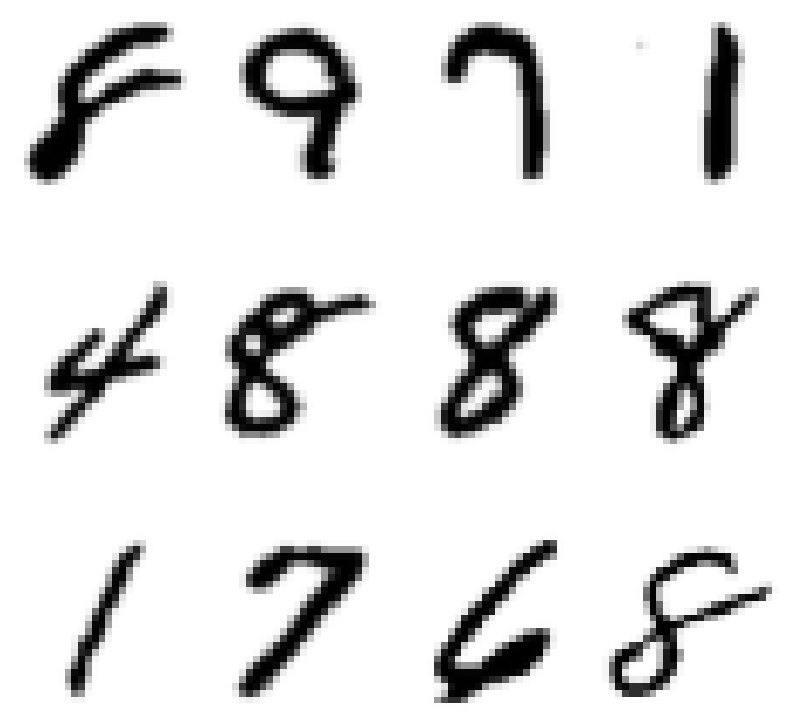

In [69]:
print(x.shape)
i = 1700
j = i + 12
pred = predictOneVsAll(all_theta, x)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))
XPrueba = x[i:j, :].copy()
print(XPrueba.shape)
#print(np.ones((1)))
#print(XPrueba)
#p = np.zeros(1)
XPrueba = np.concatenate([np.ones((12, 1)), XPrueba], axis=1)
print(XPrueba.shape)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis = 1)
print(p)

displayData(x[i:j, :])